<h1 style="text-align: center; font-family: Arial; font-weight: bold; color:green; font-size:36px;">Indigenous Energy Forecasting</h1>

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose

In [5]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Custom Functions

In [9]:
def generate_pie_chart(data, start, end, columns, title): 
    
    # Filter data by year, providing start and end year
    filtered_data = ie_power_production_df.loc[(ie_power_production_df.Year > start) & (ie_power_production_df.Year<end)]
    
    # Group by Year
    yearly_data = filtered_data.groupby('Year')[columns].sum().reset_index()

    # Add the total renewable energy production for each year
    yearly_data['Total'] = yearly_data[columns].sum(axis=1)
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=len(yearly_data),
        specs=[[{'type':'domain'}]*len(yearly_data)],
        subplot_titles=[str(year) for year in yearly_data['Year']]
    )
    
    # Loop by yearly data
    for idx, row in yearly_data.iterrows():
        fig.add_trace(
            go.Pie(
                labels=columns,  # use correct column labels
                values=[row[col] for col in columns],  # pick values for that row
                name=str(row['Year']),
                hole=0.4,
                textinfo='label+percent',  
                hoverinfo='label+percent+value',  
                title=f"Total: {row['Total']:.2f} ktoe"
            ),
            row=1, 
            col=idx+1  # index is 0-based, subplot cols start at 1
        )
    # Update Titles 
    fig.update_layout(title_text=title, height=500)

    #Render Graph
    fig.show()

def decompose(data):
    
    # Decompose data
    result = seasonal_decompose(data, model='additive')

    # Create subplots
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
    
    # Plot Observed 
    sns.lineplot(
        x=result.observed.index, 
        y=result.observed.values, 
        ax=axes[0],
        color='navy'
    )
    axes[0].set_title('Observed', loc='left')
    
    # Plot Trend
    sns.lineplot(
        x=result.trend.index, 
        y=result.trend.values, 
        ax=axes[1],
        color='green'
    )
    axes[1].set_title('Trend', loc='left')
    
    # Plot Seasonal
    sns.lineplot(
        x=result.seasonal.index, 
        y=result.seasonal.values, 
        ax=axes[2],
        color='orange'
    )
    axes[2].set_title('Seasonality', loc='left')
    
    # Plot Residuals
    sns.scatterplot(
        x=result.resid.index, 
        y=result.resid.values, 
        ax=axes[3],
        color='crimson',
        s=30  # Size of dots
    )
    axes[3].set_title('Residuals', loc='left')
    
    plt.tight_layout()
    plt.show()

# Create a function to return rows containing outliers using IQR
def check_outliers(data, feature_name):
    # Calculate the 25th and 75th percentiles
    Q1 = np.percentile(data[feature_name], 25)
    Q3 = np.percentile(data[feature_name], 75)
    # Calculate for IQR 
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 
    
    # Return records where the feature value is below the lower bound or above the upper bound
    outliers = data.loc[(data[feature_name] < lower_bound) | (data[feature_name] > upper_bound)]
    return outliers

def transform_right_skewed(data):
    #Create a variable to store the results of the testing
    transformation_df = pd.DataFrame()
    
    # Apply transformations
    transformation_df['original']=data
    transformation_df['log'] = np.log(data + 1)  # Avoid log(0)
    transformation_df['square'] = np.square(data)
    transformation_df['cbrt'] = np.cbrt(data)
    
    # Create 2 x 2 subplots 
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    
    # Log Transformation
    sns.histplot(data=transformation_df, x='original', kde=True, bins=10, ax=axes[0, 0], color='green')
    axes[0, 0].set_title('Original')
    
    # Log Transformation
    sns.histplot(data=transformation_df, x='log', kde=True, bins=10, ax=axes[0, 1], color='red')
    axes[0, 1].set_title('Distribution Plot: Log Transform')
    
    # Square Transformation
    sns.histplot(data=transformation_df, x='square', kde=True, bins=10, ax=axes[1, 0], color='orange')
    axes[1, 0].set_title('Distribution Plot: Square')
    
    # Cube Root Transformation
    sns.histplot(data=transformation_df, x='cbrt', kde=True, bins=10, ax=axes[1, 1], color='blue')
    axes[1, 1].set_title('Distribution Plot: Cube Root')

    plt.tight_layout()
    plt.show()

    # Return values
    return transformation_df



def add_features(dataframe):
   seasons = {
    'winter':[12, 1, 2],
    'spring':[3, 4, 5],
    'summer':[6, 7, 8],
    'autumn':[9,10,11],
    'start_month':[1],
    'end_month':[12]  
   }
    
   for season, months in seasons.items():
        dataframe[season] = dataframe['Month_Numeric'].isin(months).astype(int)
       
   return dataframe

## Dataset 

In [12]:
# Import Dataset
ie_power_production_df = pd.read_csv('./Datasets/AA.csv',)

# Show first 5 records
ie_power_production_df

,Year of Period,Month of Period,Unit,Coal,Combust. Renew.,Hydro,Natural Gas,Oil,Other,Peat & BM,Solar Farms,Wastes,Wind
0,2025,January,ktoe,8.8,1.1,7.5,125.0,3.3,0.1,4.7,2.5,4.6,94.7
1,2024,January,ktoe,8.6,1.1,11.3,113.8,2.4,0.1,3.4,1.5,4.8,98.2
2,2024,February,ktoe,7.4,1.0,9.8,85.3,1.0,0.1,4.6,1.7,4.3,103.0
3,2024,March,ktoe,7.5,1.2,10.0,87.7,0.5,0.1,4.2,3.0,1.9,114.4
4,2024,April,ktoe,7.1,1.1,7.6,92.2,0.4,0.1,4.4,5.6,3.3,79.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,2010,August,ktoe,19.4,0.0,1.2,121.5,1.4,1.8,7.6,0.0,0.0,17.8
177,2010,September,ktoe,18.9,0.0,4.4,118.3,0.6,1.9,14.1,0.0,0.0,24.8
178,2010,October,ktoe,23.6,0.0,3.5,113.4,0.9,1.9,19.3,0.0,0.0,27.7
179,2010,November,ktoe,25.4,0.0,8.7,122.1,1.8,1.9,19.0,0.0,0.0,29.3


# 1. Data Preparation & Visualisation

## 1.1 Data Preparation

In [16]:
ie_power_production_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year of Period   181 non-null    int64  
 1   Month of Period  181 non-null    object 
 2   Unit             181 non-null    object 
 3   Coal             181 non-null    float64
 4   Combust. Renew.  181 non-null    float64
 5   Hydro            181 non-null    float64
 6   Natural Gas      181 non-null    float64
 7   Oil              181 non-null    float64
 8   Other            181 non-null    float64
 9   Peat & BM        181 non-null    float64
 10  Solar Farms      181 non-null    float64
 11  Wastes           181 non-null    float64
 12  Wind             181 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 18.5+ KB


In [18]:
ie_power_production_df.columns

Index(['Year of Period', 'Month of Period', 'Unit', 'Coal', 'Combust. Renew.',
       'Hydro', 'Natural Gas', 'Oil', 'Other', 'Peat & BM', 'Solar Farms',
       'Wastes', 'Wind'],
      dtype='object')

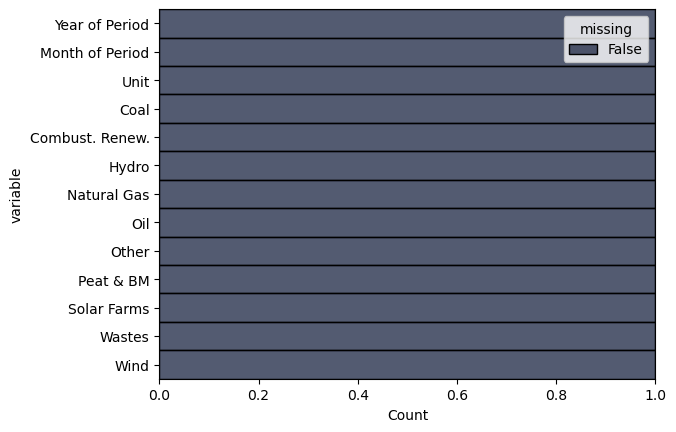

In [20]:
# Set figure pallete
sns.set_palette('cubehelix')

sns.histplot(
    data = ie_power_production_df.isnull().melt(value_name='missing'),
    y='variable',
    hue='missing',
    multiple = 'fill'
)

plt.show()

In [22]:
# Rename Columns
ie_power_production_df.nunique()

Year of Period      16
Month of Period     12
Unit                 1
Coal               136
Combust. Renew.     10
Hydro               92
Natural Gas        159
Oil                 48
Other               15
Peat & BM          103
Solar Farms         24
Wastes              34
Wind               163
dtype: int64

In [24]:
ie_power_production_df.rename(columns={
    'Year of Period':'Year',
    'Month of Period':'Month',
    'Natural Gas': 'Natural_Gas',
    'Peat & BM': 'Peat_&_BM',
    'Solar Farms': 'Solar_Farms'
}, inplace=True)

In [26]:
try:
    ie_power_production_df.drop(columns=['Unit','Combust. Renew.'], inplace=True)
except:
    print('Error in dropping columns. No changes made.')
    
ie_power_production_df.head()

,Year,Month,Coal,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind
0,2025,January,8.8,7.5,125.0,3.3,0.1,4.7,2.5,4.6,94.7
1,2024,January,8.6,11.3,113.8,2.4,0.1,3.4,1.5,4.8,98.2
2,2024,February,7.4,9.8,85.3,1.0,0.1,4.6,1.7,4.3,103.0
3,2024,March,7.5,10.0,87.7,0.5,0.1,4.2,3.0,1.9,114.4
4,2024,April,7.1,7.6,92.2,0.4,0.1,4.4,5.6,3.3,79.9


### 1.1.1 Feature Engineering

In [29]:
# Transform Months to Numeric
ie_power_production_df['Month_Numeric'] =  pd.to_datetime(ie_power_production_df['Month'], format='%B').dt.month

# Transform Year and Month to Date
ie_power_production_df['Date'] = pd.to_datetime(ie_power_production_df['Year'].astype(str) + '-' + ie_power_production_df['Month_Numeric'].astype(str).str.zfill(2) + '-01')

# Set Date as Index
ie_power_production_df.set_index('Date', inplace=True)

In [31]:
# Classify Columns to Renewable and Non-Renewable Sources
renewable_energy = ['Hydro', 'Solar_Farms', 'Wastes', 'Wind']
nonrenewable_energy = ['Coal', 'Natural_Gas', 'Oil', 'Peat_&_BM', 'Other']

# Sum all renewable energy sources
ie_power_production_df['Renewable_Energy'] = ie_power_production_df[renewable_energy].sum(axis=1)

# Sum all non-renewable energy sources
ie_power_production_df['Non_Renewable_Energy'] = ie_power_production_df[nonrenewable_energy].sum(axis=1)

# Sort Date in ascending order
ie_power_production_df.sort_index(inplace=True)

# Check dataset if changes have been made 
ie_power_production_df.head()

,Year,Month,Coal,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind,Month_Numeric,Renewable_Energy,Non_Renewable_Energy
Date,,,,,,,,,,,,,,
2010-01-01,2010,January,34.4,8.3,126.8,6.7,1.7,16.7,0.0,0.0,21.3,1,29.6,186.3
2010-02-01,2010,February,35.0,5.1,120.0,2.5,1.9,16.3,0.0,0.0,13.0,2,18.1,175.7
2010-03-01,2010,March,26.5,2.5,136.8,1.4,1.9,14.8,0.0,0.0,21.6,3,24.1,181.4
2010-04-01,2010,April,20.0,6.3,117.6,1.2,2.0,18.3,0.0,0.0,16.0,4,22.3,159.1
2010-05-01,2010,May,23.3,1.1,116.4,0.6,1.6,15.2,0.0,0.0,14.5,5,15.6,157.1


## 1.2 Data Visualisation

In [34]:
generate_pie_chart(ie_power_production_df, 2021, 2025, renewable_energy, 'Renewable Energy Production Sources for the Past 3 Years')

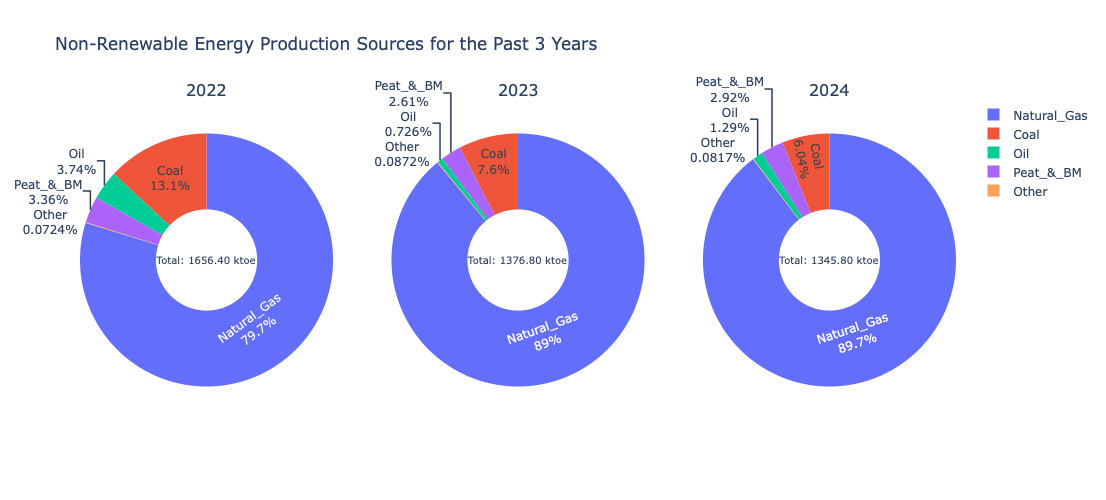

In [35]:
generate_pie_chart(ie_power_production_df, 2021, 2025, nonrenewable_energy, 'Non-Renewable Energy Production Sources for the Past 3 Years')

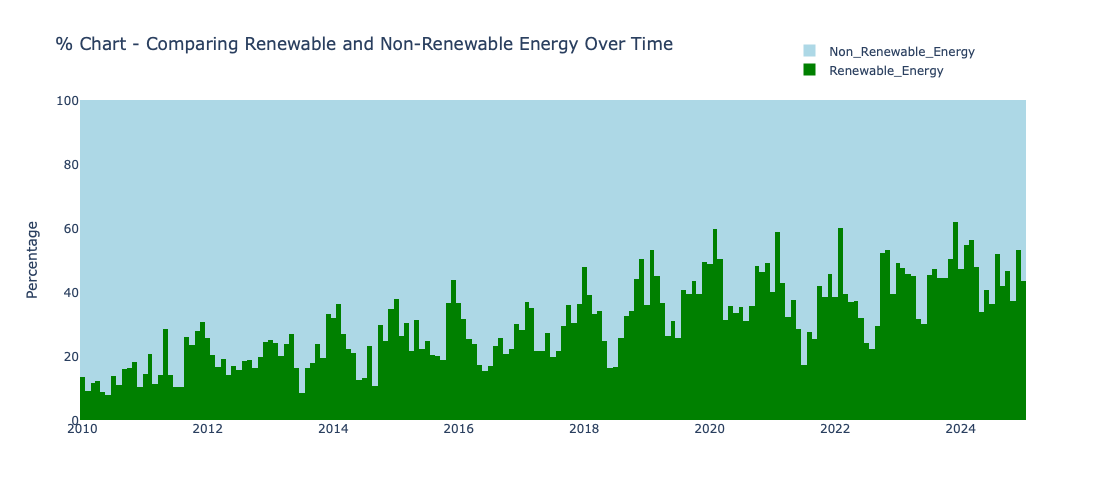

In [36]:
# Convert values to percentages by row
by_energy_group = ie_power_production_df[['Renewable_Energy', 'Non_Renewable_Energy']].copy()
by_energy_group = by_energy_group.div(by_energy_group.sum(axis=1), axis=0) * 100

fig = go.Figure()

# Define custom colors
color_map = {
    'Renewable_Energy': 'green',
    'Non_Renewable_Energy': 'lightblue'
}

for source in by_energy_group:
    fig.add_trace(go.Bar(
        x=by_energy_group.index.astype(str),  
        y=by_energy_group[source],              
        name=source,
        marker_color = color_map[source]
    ))

fig.update_layout(
    barmode='stack',
    bargap=0.02,  
    yaxis=dict(title='Percentage', range=[0, 100]),
    title_text='% Chart - Comparing Renewable and Non-Renewable Energy Over Time',
    legend=dict(
        x=0.75,
        y=1.2,
        xanchor='left', 
        yanchor='top'
    ),
    height=500,
    width=1100
)

fig.update_traces(marker_line_width=0)

fig.show()

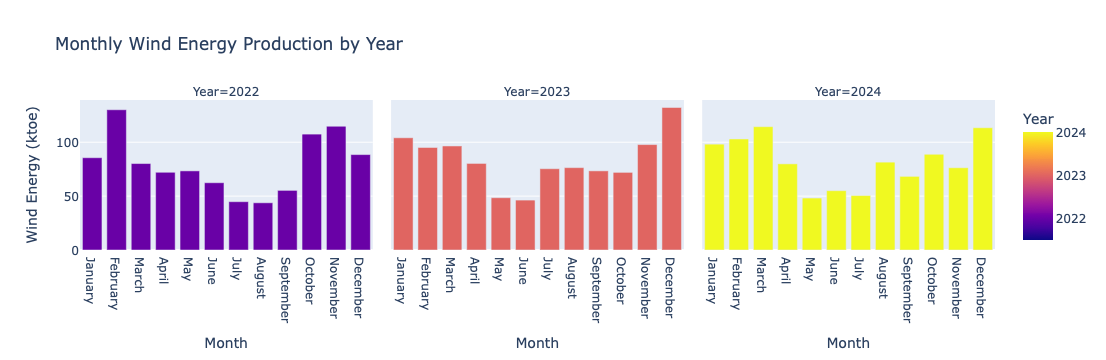

In [40]:
start_year=2021
end_year=2025
filtered_data=ie_power_production_df.loc[(ie_power_production_df.Year>start_year) & (ie_power_production_df.Year<end_year)]

fig = px.bar(
    filtered_data,
    x='Month',   
    y='Wind',             
    color='Year',         
    barmode='group',      
    facet_col='Year',  
    labels={
        'Month_Numeric':'Month',
        'Wind':'Wind Energy (ktoe)'
    },
    title='Monthly Wind Energy Production by Year',
)

fig.show()

## 1.3 Exploratory Data Analysis

### 1.3.1 Outlier Checking and Handling

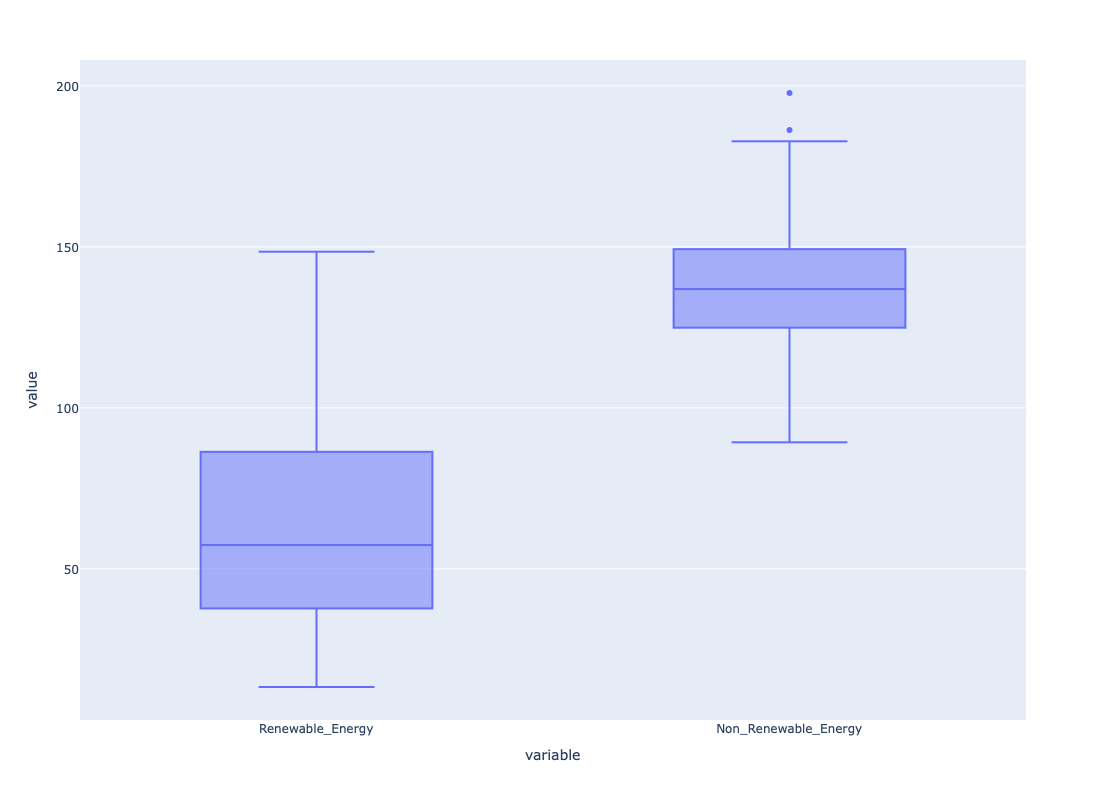

In [43]:
fig = px.box(ie_power_production_df[['Renewable_Energy', 'Non_Renewable_Energy']])
fig.update_layout(height=800, width=800)
fig.show()

In [45]:
outliers=check_outliers(ie_power_production_df, 'Non_Renewable_Energy')
outliers.reset_index(inplace=True)
outliers

,Date,Year,Month,Coal,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind,Month_Numeric,Renewable_Energy,Non_Renewable_Energy
0,2010-01-01,2010,January,34.4,8.3,126.8,6.7,1.7,16.7,0.0,0.0,21.3,1,29.6,186.3
1,2010-12-01,2010,December,36.6,4.4,135.3,6.1,1.8,18.0,0.0,0.0,18.8,12,23.2,197.8


In [48]:
# Replace value with 
ie_power_production_df.loc[outliers.Date,'Non_Renewable_Energy']= np.nan
ie_power_production_df.Non_Renewable_Energy.interpolate(method='linear', limit_direction='both', inplace=True)
ie_power_production_df.loc[outliers.Date.values]



,Year,Month,Coal,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind,Month_Numeric,Renewable_Energy,Non_Renewable_Energy
Date,,,,,,,,,,,,,,
2010-01-01,2010,January,34.4,8.3,126.8,6.7,1.7,16.7,0.0,0.0,21.3,1,29.6,175.7
2010-12-01,2010,December,36.6,4.4,135.3,6.1,1.8,18.0,0.0,0.0,18.8,12,23.2,176.5


## Scatterplot with Trend Line

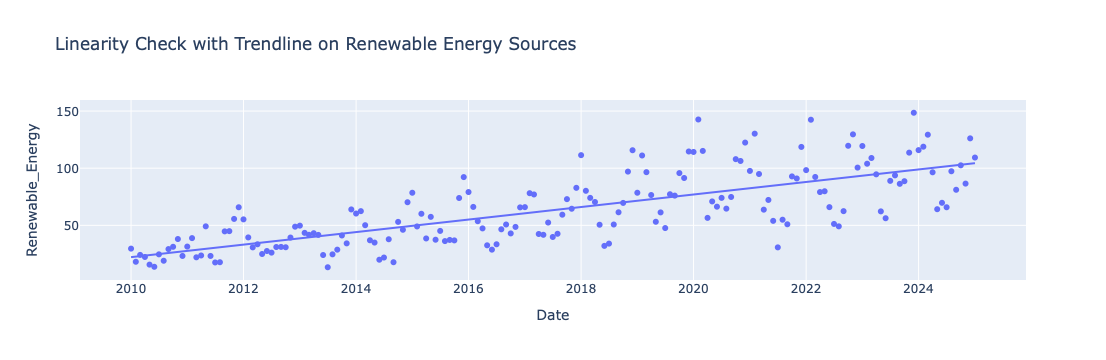

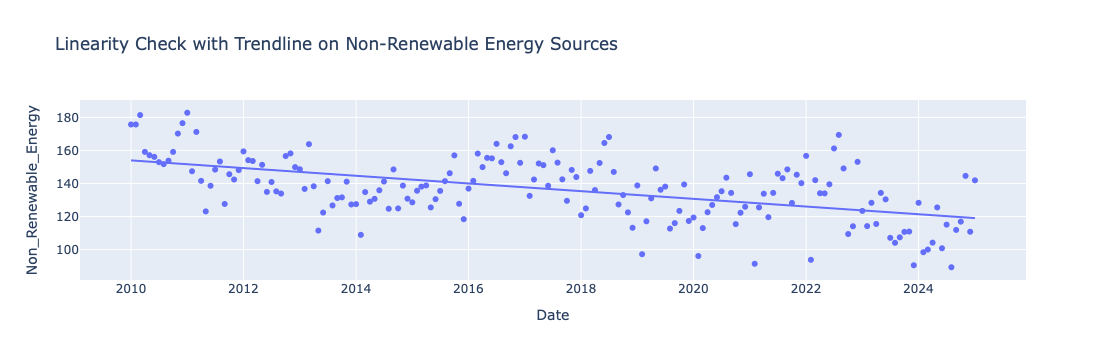

In [51]:
fig = px.scatter(
    ie_power_production_df,
    x=ie_power_production_df.index,
    y='Renewable_Energy',
    trendline='ols', 
    title='Linearity Check with Trendline on Renewable Energy Sources',
    labels={
        'total_energy_import': 'Energy (ktoe)'
    }
)
fig.show()

fig = px.scatter(
    ie_power_production_df,
    x=ie_power_production_df.index,
    y='Non_Renewable_Energy',
    trendline='ols', 
    title='Linearity Check with Trendline on Non-Renewable Energy Sources',
    labels={
        'total_energy_import': 'Energy (ktoe)'
    }
)
fig.show()

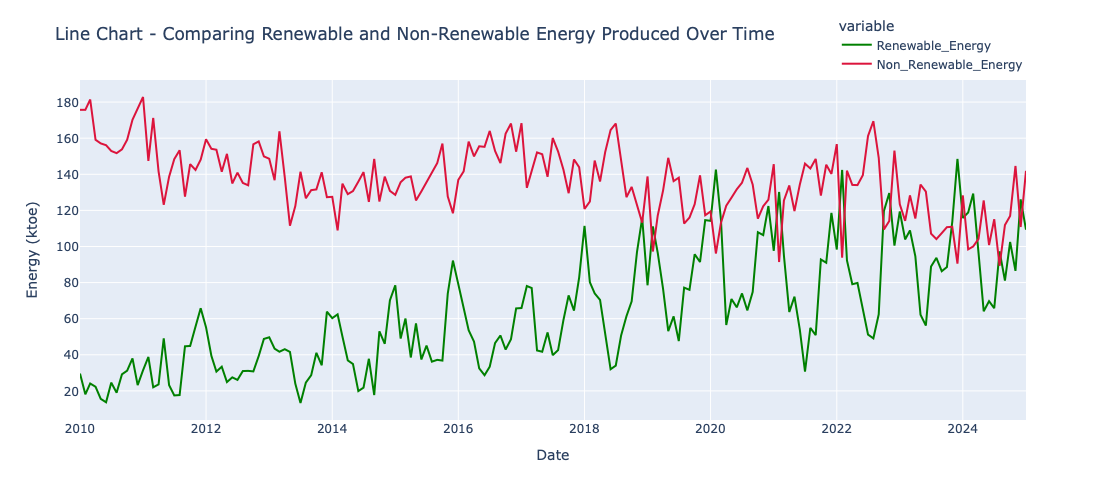

In [698]:
color_map['Non_Renewable_Energy']='crimson'

for i in ['Renewable_Energy', 'Non_Renewable_Energy'],:
    fig = px.line(ie_power_production_df, 
                  x=ie_power_production_df.index, 
                  y=i,
                  color_discrete_map=color_map,
                  labels={'value':'Energy (ktoe)',
                         'date':'Year'})
    
    fig.update_layout(
    title_text='Line Chart - Comparing Renewable and Non-Renewable Energy Produced Over Time',
    legend=dict(
        x=0.8,
        y=1.2,
        xanchor='left', 
        yanchor='top'
    ),
    height=500,
    width=1100)

fig.show()

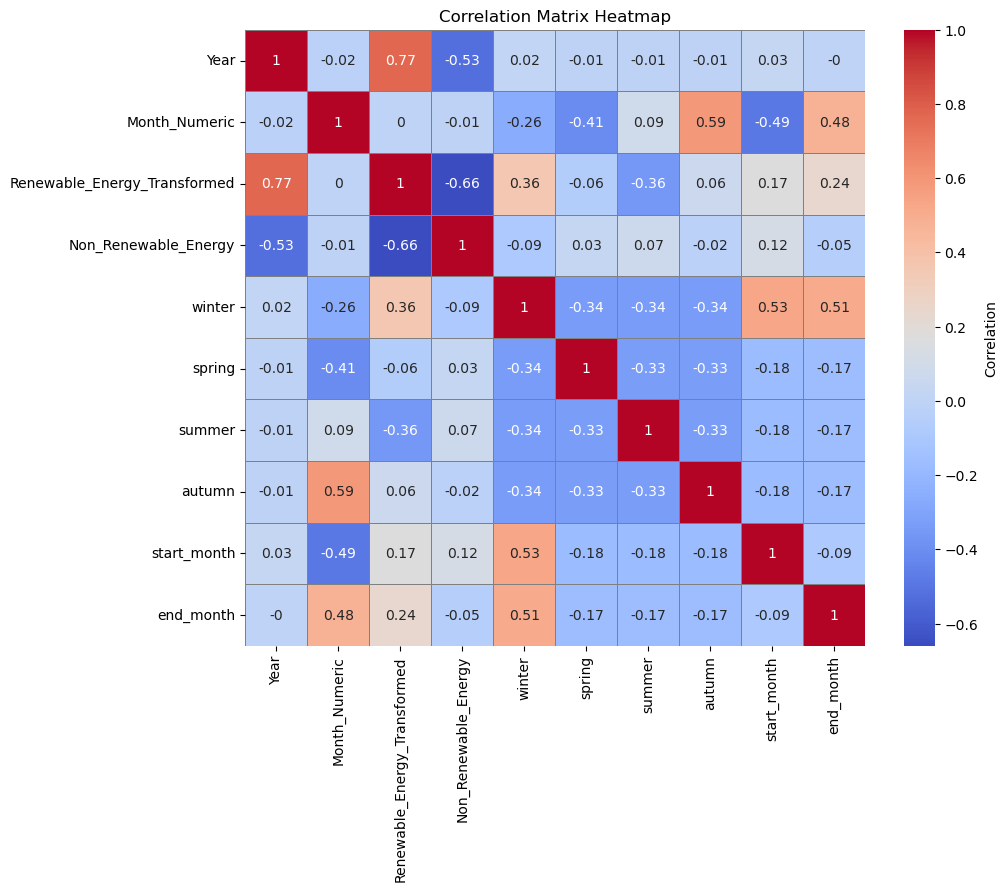

In [565]:
#Add More Features in the Dataset
modelling_data=add_features(ie_power_production_df[['Year', 'Month_Numeric', 'Renewable_Energy_Transformed', 'Non_Renewable_Energy']])

corr_matrix = modelling_data.corr(numeric_only=True).round(2)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,     
    cmap='coolwarm',  
    cbar_kws={'label': 'Correlation'}, 
    linewidths=0.5,  
    linecolor='gray'
)

# Add title and display
plt.title('Correlation Matrix Heatmap')
plt.show()

# 2. Statistics

In [986]:
ie_power_production_df[['Renewable_Energy_Transformed','Non_Renewable_Energy']].describe()

,Renewable_Energy_Transformed,Non_Renewable_Energy
count,181.000000,181.000000
mean,3.867438,136.552486
std,0.685577,19.070587
min,2.369285,89.300000
25%,3.356067,124.900000
50%,3.857482,136.900000
75%,4.419132,149.100000
max,5.295523,182.800000


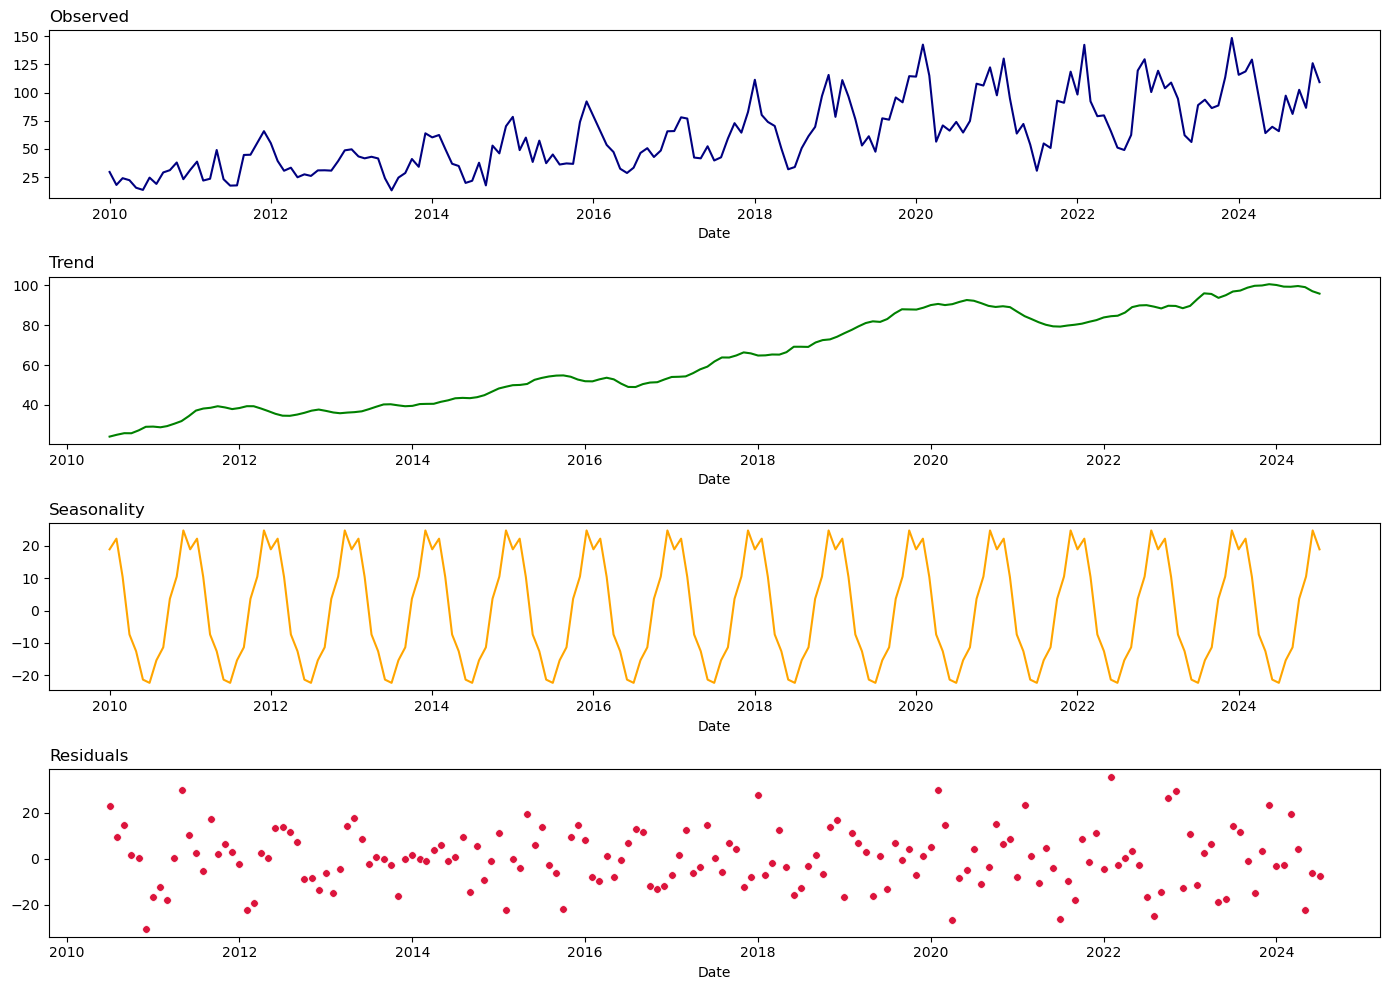

In [750]:
decompose(ie_power_production_df.Renewable_Energy)

## 2.1 Normal Distribution Plot

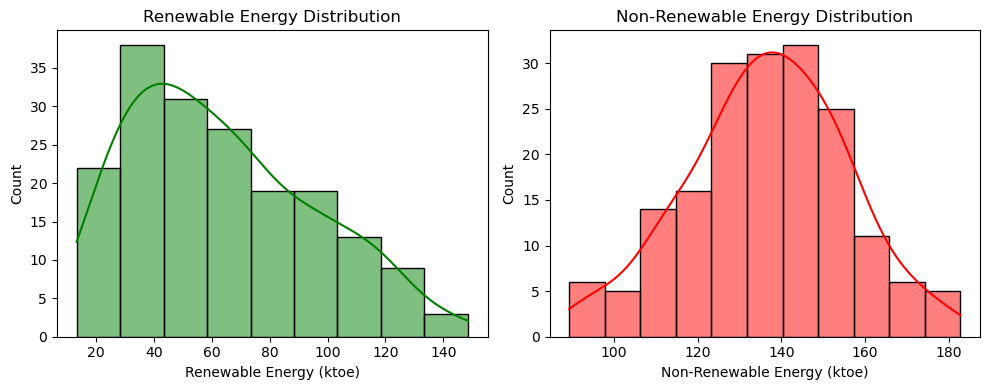

In [947]:
# Create subplots: 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  

# Generate Renewable Energy Histogram
sns.histplot(
    ie_power_production_df.Renewable_Energy,
    kde=True,
    color='green', 
    ax=axes[0]
)
axes[0].set_title('Renewable Energy Distribution')
axes[0].set_xlabel('Renewable Energy (ktoe)')

# Non-Renewable Energy Histogram
sns.histplot(
    ie_power_production_df.Non_Renewable_Energy,
    kde=True,
    color='red',    
    ax=axes[1]
)
axes[1].set_title('Non-Renewable Energy Distribution')
axes[1].set_xlabel('Non-Renewable Energy (ktoe)')

# Adjust layout
plt.tight_layout()
plt.show()

### 2.1.1 Transform Data into Normal Distribution 

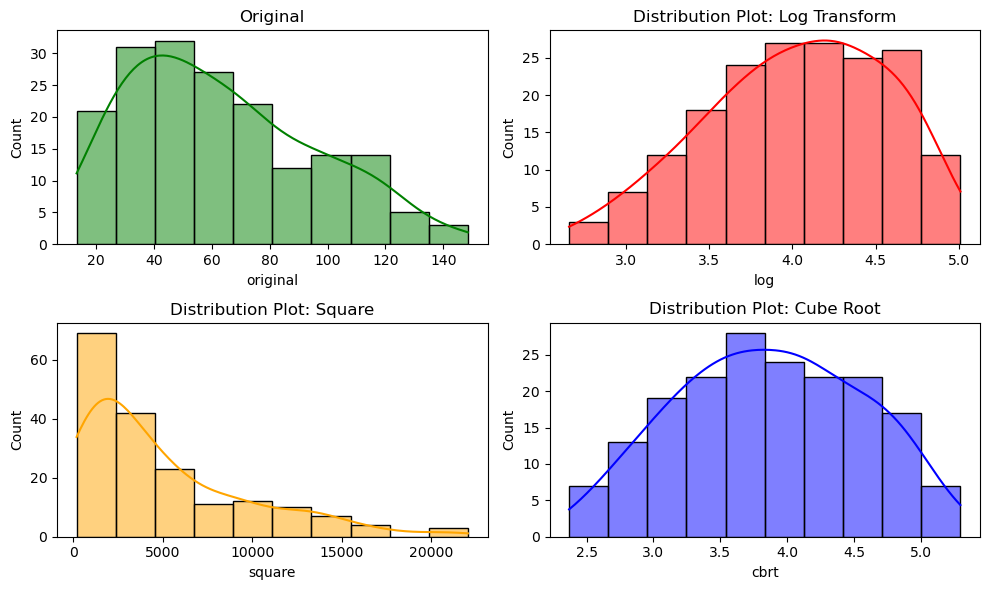

In [526]:
transformed_data=transform_right_skewed(ie_power_production_df.Renewable_Energy)
ie_power_production_df['Renewable_Energy_Transformed'] = transformed_data['cbrt']

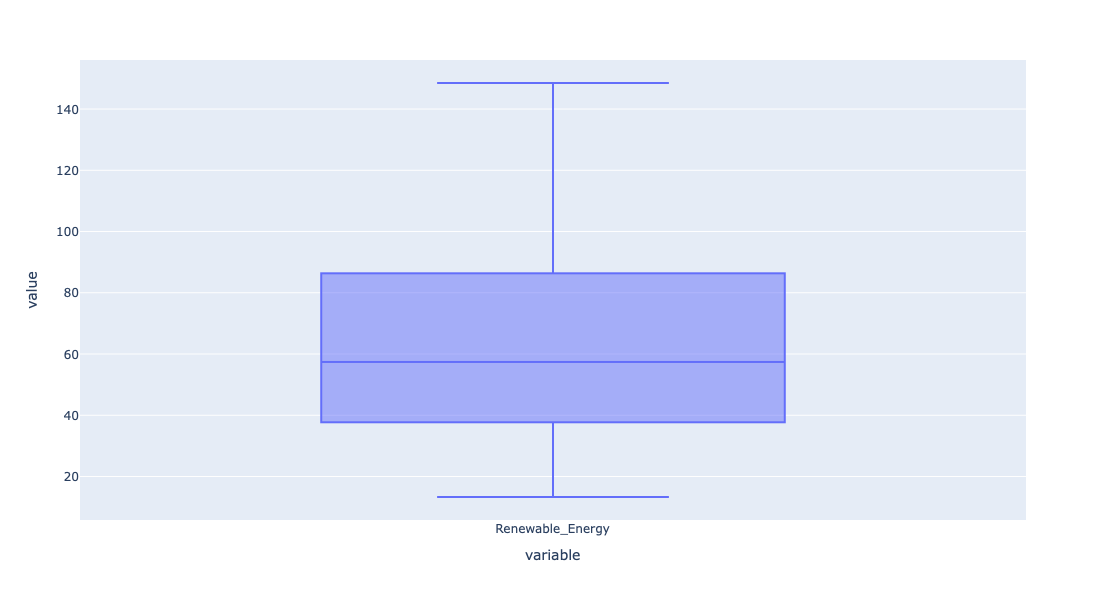

In [53]:
fig = px.box(ie_power_production_df.Renewable_Energy)
fig.update_layout(height=600, width=600)
fig

## 2.2 Hypothesis Testing

In [973]:
## Check if columns are Stationary
from statsmodels.tsa.stattools import adfuller
from scipy.stats import shapiro, kruskal, pearsonr, spearmanr, kruskal
from statsmodels.stats.diagnostic import linear_reset

# Check if data is stationary
#Ho: It is non stationary
#H1: It is stationary
def adfuller_test(data):
    result=adfuller(data)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("Weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")


# Check id data is in normal distribution
#Ho: Data is in normal distribution
#H1": Data is not in normal distribution
def shapirowilk_test(data):
    stat, p_value = shapiro(data)

    if p_value > 0.05:
        print(f'p_value:{p_value:.2f}, Fail to reject Ho, data is in normal distribution.')
    else:
        print(f'p_value:{p_value:.2f}, Reject Ho, data is in not normal distribution.')


def pearson_test(X,y): 
    for col in X.select_dtypes(include='number').columns:
        r, p = pearsonr(X[col], y)
        print(f"{col}: p-value = {p:.4f}")
        if p < 0.05:
            print("Significant relationship with target (reject Ho)")
        else:
            print("No significant relationship (fail to reject Ho)")
        print('\n')


def reset_linearity_test(y):
    t = np.arange(len(y))
    X = sm.add_constant(t)
    model = sm.OLS(y, X).fit()

    result = linear_reset(model, power=2, use_f=True)
    print(f"RESET test p-value: {result.pvalue:.4f}")

    if result.pvalue < 0.05:
        print("Reject H0: Evidence of non-linearity.")
    else:
        print("Fail to reject H0: No clear evidence of non-linearity.")
    print('\n')

def seasonality_kruskal_test(y, period=12):
    y = np.array(y)
    n = len(y)

    if n < period * 2:
        print("Warning: Not enough data to assess seasonality.")
        return

    # Split y into seasonal groups
    seasonal_groups = [y[i::period] for i in range(period)]

    stat, p = kruskal(*seasonal_groups)
    print(f"Kruskal-Wallis test p-value: {p:.4f}")

    if p < 0.05:
        print("Reject H0: Evidence of seasonality (at least one group differs).")
    else:
        print("Fail to reject H0: No clear evidence of seasonality.")
    print('\n')


In [975]:
seasonality_kruskal_test(ie_power_production_df.Renewable_Energy_Transformed)

seasonality_kruskal_test(ie_power_production_df.Non_Renewable_Energy)

Kruskal-Wallis test p-value: 0.0000
Reject H0: Evidence of seasonality (at least one group differs).


Kruskal-Wallis test p-value: 0.4606
Fail to reject H0: No clear evidence of seasonality.




In [977]:
reset_linearity_test(ie_power_production_df.Renewable_Energy_Transformed)

reset_linearity_test(ie_power_production_df.Non_Renewable_Energy)

RESET test p-value: 0.0675
Fail to reject H0: No clear evidence of non-linearity.


RESET test p-value: 0.8609
Fail to reject H0: No clear evidence of non-linearity.




In [979]:
columns=['Year', 'Month_Numeric', 'winter', 'spring', 'summer', 'autumn','start_month', 'end_month']
pearson_test(ie_power_production_df[columns], ie_power_production_df.Renewable_Energy)

Year: p-value = 0.0000
Significant relationship with target (reject Ho)


Month_Numeric: p-value = 0.9843
No significant relationship (fail to reject Ho)


winter: p-value = 0.0000
Significant relationship with target (reject Ho)


spring: p-value = 0.2782
No significant relationship (fail to reject Ho)


summer: p-value = 0.0000
Significant relationship with target (reject Ho)


autumn: p-value = 0.6245
No significant relationship (fail to reject Ho)


start_month: p-value = 0.0198
Significant relationship with target (reject Ho)


end_month: p-value = 0.0004
Significant relationship with target (reject Ho)




In [981]:
shapirowilk_test(ie_power_production_df.Non_Renewable_Energy)
shapirowilk_test(ie_power_production_df.Renewable_Energy)
shapirowilk_test(ie_power_production_df.Renewable_Energy_Transformed)

p_value:0.67, Fail to reject Ho, data is in normal distribution.
p_value:0.00, Reject Ho, data is in not normal distribution.
p_value:0.04, Reject Ho, data is in not normal distribution.


In [983]:
nonrenewable_shifted_df=ie_power_production_df['Non_Renewable_Energy'].reset_index()
nonrenewable_shifted_df['first_diff']= nonrenewable_shifted_df.Non_Renewable_Energy - nonrenewable_shifted_df.Non_Renewable_Energy.shift(1)
adfuller_test(nonrenewable_shifted_df.first_diff.dropna())

print('\n')
renewable_energy_shifted=ie_power_production_df['Renewable_Energy'].reset_index()
renewable_energy_shifted['first_diff']= renewable_energy_shifted.Renewable_Energy - renewable_energy_shifted.Renewable_Energy.shift(1)
adfuller_test(renewable_energy_shifted.first_diff.dropna())

ADF Test Statistic : -6.839758850385808
p-value : 1.8038044154307868e-09
#Lags Used : 10
Number of Observations Used : 169
Strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


ADF Test Statistic : -4.3882445360343825
p-value : 0.00031137932901683925
#Lags Used : 14
Number of Observations Used : 165
Strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


# 4. Machine Learning

In [901]:
from sklearn.model_selection import train_test_split

# Create Train test split
X=ie_power_production_df[columns]
y=ie_power_production_df['Renewable_Energy']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0, shuffle = False)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((144, 8), (37, 8), (144,), (37,))